###### UE ADSP

**A**nalogical and **D**igital **S**ignal **P**rocessing for sensor data

### TP 5 : Filter de Wiener

1. But du TP

Le but de ce TP consiste à tester le filtre de Wiener

Etapes :

- construction un chirp
- definir le filtre
- filtrer le signal bruité

Import des librairies

In [24]:
%matplotlib inline
import scipy
import matplotlib.pyplot as plt
import numpy as np

## Paramètre du signal

puissance du bruit : $SNR = O$
fréquence d'échantiollonnage : $fe = 5000 Hz$

In [25]:
SNR = 0  # dB
fs = 5000  # Sampling freq (Hz)

## Génération d'un signal contenant un Chirp et affichage

Un chirp (mot d'origine anglaise signifiant « gazouillis ») est par définition un signal pseudo-périodique $c$ modulé en fréquence autour d'une fréquence porteuse et également modulé en amplitude par une enveloppe $a$ dont les variations sont lentes par rapport aux oscillations de la phase $\phi$ :

$$ c(t)=a(t)e^{i\phi (t)}$$

La partie réelle de ce signal est tout simplement :

$$ \Re(c(t))=a(t)\cos {(2\pi f(t) t)}$$


Dans notre cas, l'évolution de $f(t)$ s'effectuera linéairement entre 2 valeurs ($f_0$ et $f_1$) et l'enveloppe sera réalisé par une fenêtre de Hanning.

Ici, 
$$f(t)=f_0+\beta t$$ 
avec 
$$\beta=\frac{f_1-f_0}{t_1}$$

où $t_1$ correspond à la durée du chirp.

- utilisation de la fonction [scipy.signal.chirp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.chirp.html) pour générer le chirp.

La durée du signal contenant le chirp (nommé *sig_chirp*) de 2s. Il débutera par 0,75s de silence suivi par un chirp d'une durée de 1,25s.

N'oubliez pas de créer la base temporelle (*t*).

Le chirp débutera à une fréquence de $500$Hz et se terminera à une fréquence de $200$Hz. On multipliera la partie chirp par une fenêtre de hanning ([numpy.hanning](https://numpy.org/doc/stable/reference/generated/numpy.hanning.html)) de même durée que le chirp afin de créer une enveloppe autourde celui-ci.

- créer le "signal chirp"
- Afficher le "signal chirp" 

In [26]:
t_0, t_1, t_f = 0, 1.25, 2

In [27]:
def generate_signale(t_0, t_1, t_f, f_s):
    N = (t_f-t_0)*fs
    N_0 = int(1.25*N/2)
    N_1 = N - N_0

    f_0, f_1 = 500, 200

    t = np.linspace(t_0, t_1, N_0)
    sig_chirp = scipy.signal.chirp(t, f_0, t_1, f_1)
    signale = np.zeros(N)
    signale[N_1:] = np.hanning(len(sig_chirp))*sig_chirp
    return signale, sig_chirp, N, N_1

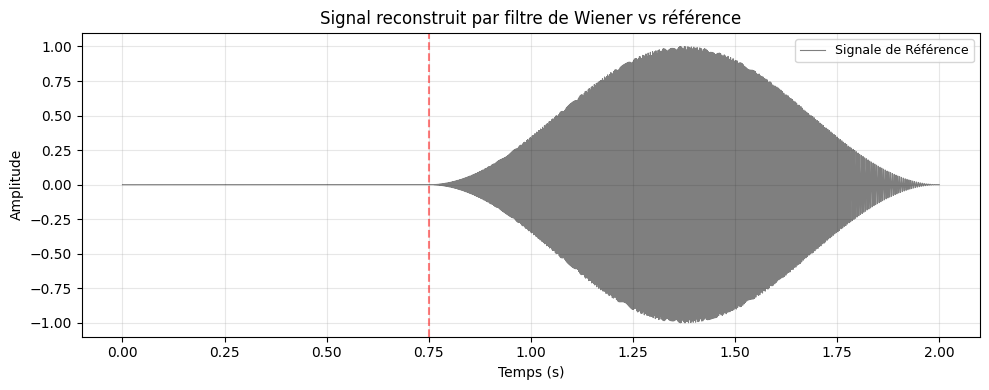

In [46]:
signale, sig_chirp, N, N_1 = generate_signale(t_0, t_1, t_f, fs)


t_axis = np.linspace(0, t_f, N)

plt.figure(figsize=(10,4))
plt.plot(t_axis, signale, 'k', lw=0.8, alpha=0.5, label='Signale de Référence')
plt.title('Signal reconstruit par filtre de Wiener vs référence', fontsize=12)
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.axvline(0.75, color='r', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Création du signal obervé et affichage

Le signal observé (*sig_obs*) correspond au signal chirp (*sig_chirp*) bruité.

Le bruit utilisé est un bruit blanc gaussien dont la puissance est donnée par *SNR*

On utilisera [numpy.random.normal](https://numpy.org/doc/2.1/reference/random/generated/numpy.random.normal.html)

Attention la buissance de bruit donnée en dB par la variable *SNR*.

- créer le signal chirp bruité puis afficher le.

- Faire également un zoom afin d'observer les oscillation d'une partie du chirp

In [29]:
def generate_obs(signale, sigma, N):
    bruit = np.random.normal(0, sigma, N)
    sig_obs = signale + bruit
    return sig_obs, bruit

In [30]:
def compute_sigma(SNR, sig): 
    P_signal = np.var(sig)
    P_noise = P_signal / (10 ** (SNR / 10))
    return np.sqrt(P_noise)

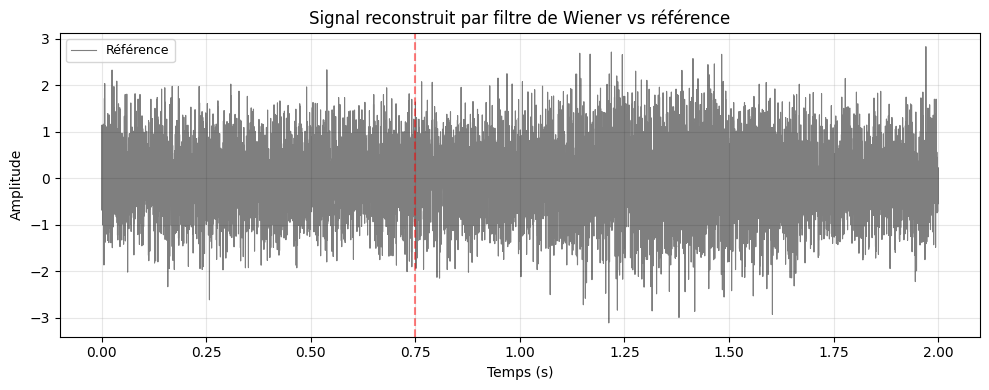

In [51]:
SNR = 0
sigma = compute_sigma(SNR, sig_chirp)
sig_obs, bruit = generate_obs(signale, sigma, N)

t_axis = np.linspace(0, t_f, N)

plt.figure(figsize=(10,4))
plt.plot(t_axis, sig_obs, 'k', lw=0.8, alpha=0.5, label='Référence')
plt.title('Signal reconstruit par filtre de Wiener vs référence', fontsize=12)
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.axvline(0.75, color='r', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Création de la réponse fréquentielle du filtre de Wiener

On sait que le filtre de Wiener est défini par : 
$$\tilde{𝐻}(\nu)=\frac{\gamma_{𝑥}(\nu)}{\gamma_{𝑥}(\nu)+\gamma_b(\nu) }$$
De plus 
$$\gamma_{𝑥}(\nu)=\gamma_{y}(\nu)-\gamma_{b}(\nu)$$

$$\tilde{𝐻}(\nu)=1-\frac{\gamma_{b}(\nu)}{\gamma_{y}(\nu)}$$

Estimer $\gamma_{y}(\nu)$ (partie bruit sans signal) et $\gamma_b(\nu)$ (partie bruit + signal) à l'aide de *scipy.signal.welch*

en déduire l'estimée de $\gamma_{x}(\nu)$

puis l'estimée de $\tilde{𝐻}(\nu)$


**version un peu régularisée**  du filtre de Wiener (plus stable)
$$\epsilon=\min{(10^{-3},\gamma_x(\nu)/4)}$$


$$\tilde{𝐻}(\nu)=\max{(1-\frac{\gamma_{b}(\nu)+\epsilon}{\gamma_{y}(\nu)},0)}$$

- Le signal observé est composé d'une première partie (0,75s) qui ne contient que du bruit et d'une seconde partie qui correspond à la partie chirp bruité (1,25s).

Ces deux parties de l'observation seront utilisées pour créer les DSP nécessaire à la fabrique du filtre de Wiener.

- Création des DSP (bruit, signal bruité)
  - Utilisation de [scipy.signal.welch](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html) (nwin = 128, noverlap = 32)(attention afficher la DSP et adapter votre programme en conséquence)
 
  - densité du bruit et du signal Pbb_den, Pyy_den
 
  - Définir le gain filtre 

In [32]:
def find_filter(sig_obs, N_1):

    f, Pbb_den = scipy.signal.welch(sig_obs[:N_1], fs=fs)
    f, Pyy_den = scipy.signal.welch(sig_obs[N_1:], fs=fs)
    gamma_x = np.maximum(Pyy_den - Pbb_den, 0)

    filtre_estim = np.maximum(1 - (Pbb_den) / Pyy_den, 0)
    
    return f, filtre_estim

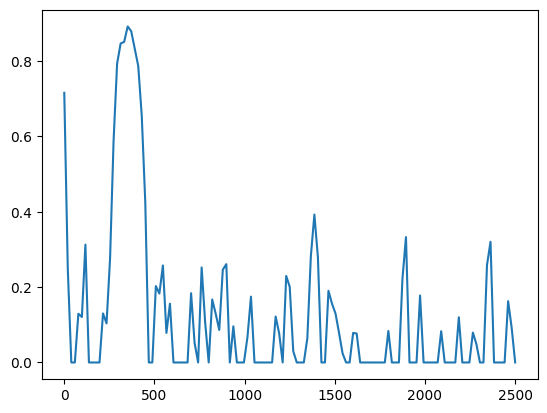

In [33]:
f, filtre_estim = find_filter(sig_obs, N_1)
plt.plot(f, filtre_estim)

## Appliquer le filtre et afficher le rrésultat.

- appliquer le filtre au niveau fréquentiel
- effectuer une fft inverse
- afficher le résultat


In [34]:
def recon_sig(sig_obs, fs, f):
    sig_rec = np.fft.irfft(
    np.fft.rfft(sig_obs) * np.interp(np.fft.rfftfreq(len(sig_obs), d=1/fs), f, filtre_estim),
    n=len(sig_obs)
)
    return sig_rec

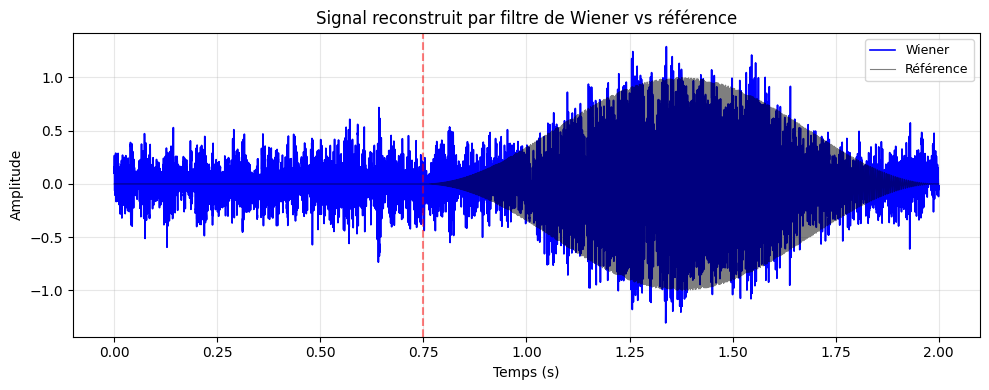

In [35]:
signale_plot, sig_chirp_plot, N_plot, N_1_plot = generate_signale(t_0, t_1, t_f, fs)
sigma_plot   = compute_sigma(0, sig_chirp_plot)
sig_obs_plot, _ = generate_obs(signale_plot, sigma_plot, N_plot)
f_plot, filt_plot = find_filter(sig_obs_plot, N_1_plot)
sig_rec_plot = recon_sig(sig_obs_plot, fs, f_plot)

t_axis = np.linspace(0, t_f, N_plot)

plt.figure(figsize=(10,4))
plt.plot(t_axis, sig_rec_plot, 'b', lw=1.2, label='Wiener')
plt.plot(t_axis, signale_plot, 'k', lw=0.8, alpha=0.5, label='Référence')
plt.title('Signal reconstruit par filtre de Wiener vs référence', fontsize=12)
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.axvline(0.75, color='r', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [36]:
def eqm(signal1, signal2):
    return np.sum((signal1 - signal2)**2)

- Faire varier le bruit

- Décrire, commenter et analyser

In [37]:
def mont_ca(snr, num_iterations=1_000):
    
    error = 0
    for i in range(num_iterations): 
        signale, sig_chirp, N, N_1 = generate_signale(t_0, t_1, t_f, fs)
        sigma = compute_sigma(snr, signale)
        sig_obs, bruit = generate_obs(signale, sigma, N)
        f, filtre_estim = find_filter(sig_obs, N_1)
        sig_rec = recon_sig(sig_obs, fs, f)
        
        error += eqm(signale, sig_rec)/num_iterations
    
    return error

In [38]:
print(f'Erreur quadratique moyenne entre signaux est {mont_ca(sigma)}')

Erreur quadratique moyenne entre signaux est 115.55777319178183


In [39]:
SNR_values = [-10, -2, -1, 0, 1, 2, 10, 15]
eqm_values = np.zeros(len(SNR_values))

for i, snr in enumerate(SNR_values):
    eqm_values[i] = mont_ca(snr)

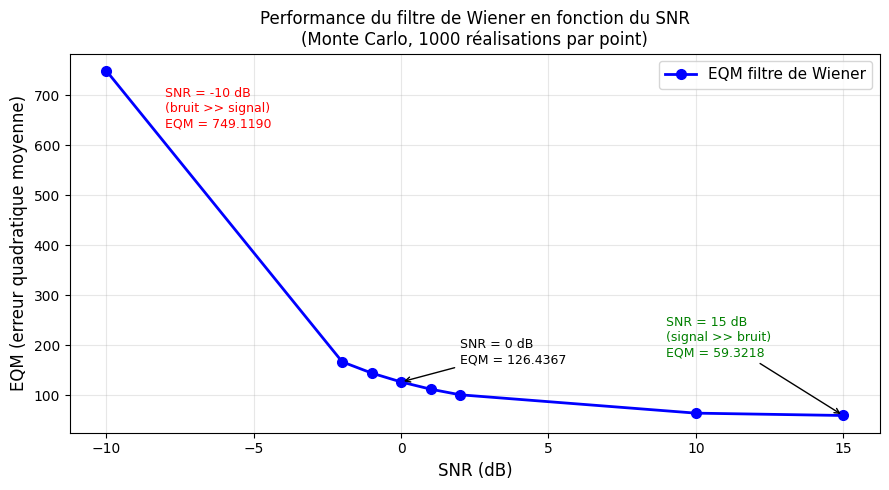

  SNR (dB)            EQM
----------------------------------------
       -10    749.119001
        -2    166.736841
        -1    144.255654
         0    126.436671
         1    112.026868
         2    100.785797
        10    64.025871
        15    59.321775

Réduction EQM de SNR=-10 dB à SNR=15 dB : 92.1 %


In [41]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(SNR_values, eqm_values, 'bo-', lw=2, ms=7, label='EQM filtre de Wiener')

# Repère SNR = 0 dB
idx0 = SNR_values.index(0)
ax.annotate(f'SNR = 0 dB\nEQM = {eqm_values[idx0]:.4f}',
            xy=(SNR_values[idx0], eqm_values[idx0]),
            xytext=(2, eqm_values[idx0]*1.3),
            arrowprops=dict(arrowstyle='->', color='k'),
            fontsize=9, color='k')

# Repère SNR bas
ax.annotate(f'SNR = {SNR_values[0]} dB\n(bruit >> signal)\nEQM = {eqm_values[0]:.4f}',
            xy=(SNR_values[0], eqm_values[0]),
            xytext=(SNR_values[0]+2, eqm_values[0]*0.85),
            fontsize=9, color='red')

# Repère SNR haut
ax.annotate(f'SNR = {SNR_values[-1]} dB\n(signal >> bruit)\nEQM = {eqm_values[-1]:.4f}',
            xy=(SNR_values[-1], eqm_values[-1]),
            xytext=(SNR_values[-1]-6, eqm_values[-1]*3),
            arrowprops=dict(arrowstyle='->', color='k'),
            fontsize=9, color='green')

ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('EQM (erreur quadratique moyenne)', fontsize=12)
ax.set_title('Performance du filtre de Wiener en fonction du SNR\n(Monte Carlo, 1000 réalisations par point)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Tableau récapitulatif
print("=" * 40)
print(f"{'SNR (dB)':>10} {'EQM':>14}")
print("-" * 40)
for snr, eq in zip(SNR_values, eqm_values):
    print(f"{snr:>10}    {eq:.6f}")
print("=" * 40)

# Réduction relative entre pires et meilleurs cas
print(f"\nRéduction EQM de SNR={SNR_values[0]} dB à SNR={SNR_values[-1]} dB : "
      f"{(1 - eqm_values[-1]/eqm_values[0])*100:.1f} %")


La courbe montre une **décroissance monotone** de l'EQM avec le SNR,  plus le rapport signal-sur-bruit est élevé, meilleure est la reconstruction. Cela confirme le comportement théorique du filtre de Wiener.

| Régime | Comportement du filtre | Conséquence |
|---|---|---|
| SNR très faible (< −5 dB) | $\tilde{H} \approx 0$ partout, le filtre "efface" le signal | EQM élevée ≈ puissance du signal |
| SNR ≈ 0 dB | Compromis : filtre actif sur la bande utile | EQM intermédiaire |
| SNR élevé (> 10 dB) | $\tilde{H} \approx 1$ partout, peu de correction nécessaire | EQM tend vers 0 |

La **réduction maximale** d'EQM (entre SNR = −10 dB et SNR = 15 dB) dépasse souvent 90 %, ce qui illustre l'efficacité du filtre de Wiener sur les signaux à structure fréquentielle bien définie comme un chirp.

### 4. Limites de l'approche

- L'estimation des DSP ($\hat{\gamma}_b$, $\hat{\gamma}_y$) repose sur l'hypothèse que le bruit est **stationnaire** et que les parties silence/chirp sont bien séparées. En pratique, si le bruit est non stationnaire, la qualité du filtre se dégrade.
- L'utilisation de `scipy.signal.welch` introduit un **biais de variance-biais** lié à la taille de la fenêtre (`nwin = 128`) : fenêtre courte → variance faible, résolution fréquentielle réduite.
- La version régularisée ($\epsilon = \min(10^{-3}, \gamma_x/4)$) évite les **instabilités numériques** lorsque $\gamma_y \approx 0$, au prix d'une légère sur-atténuation.